# Interactive Script: **get_stac_layers**

**Author:** Baturalp Arisoy

## Contents

1. [How to **get_stac_layers**](#1-how-to-get_stac_layers)
2. [Slice Time and Band](#2-slice-time-and-band)
3. [Calculate Stats](#3-calculate-stats)
4. [Export and Read](#4-export-and-read)
5. [Simple Visualization](#5-simple-visualization)
6. [Graphs and Animation](#6-graphs-and-animation)

---

**Imports**

In [1]:
from stac2ardcube import get_stac_layers
import xarray as xr
import numpy as np
import dask
from dask.diagnostics import ProgressBar
import rioxarray
import matplotlib.pyplot as plt
import pandas as pd

## 1. How to **get_stac_layers**

**1.1 Set the parameters**

In [2]:
mission = "s2"
polygon = "./polygons/test.gpkg"
resolution = 10
daterange = ["2022-01-01", "2024-12-31"]
bands = ["blue", "green", "red", "nir",]
max_cc = 100
clip_raster = False
cloud_masking = False
indices = ["ndvi", "ndwi"]
output = None # Will return lazy, replace with path to export, preferably with DSS container path
stats = None
aggregator = None
topographic_features = None
animation = False

**(Optional) 1.1.1 If polygon is not available, select your area below on Leafmap**

In [3]:
#!pip install leafmap
# restart Kernel

import leafmap

**(Optional) 1.1.2 Change the extent**<br>
Adjust the extent and execute 1.1.3. The extent will be bbox.

In [ ]:
m = leafmap.Map(center=[49.787281735930804, 9.978161492015976], zoom=18, height="800px")
m

**(Optional) 1.1.3 Get the bbox coordinate list**

In [9]:
bbox = (m.west, m.south, m.east, m.north)
polygon = list(bbox)

**1.2 Get Stac Layers, returns lazy xarray.DataArray**

In [3]:
stac = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats,
                            topographic_features=topographic_features, animation=animation)

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 419, band: 6, y: 247, x: 511)> Size: 3GB
dask.array<transpose, shape=(419, 6, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 3kB 2022-01-02 2022-01-04 ... 2024-12-29
    spatial_ref  int64 8B 0


In [11]:
stac

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 419, band: 6, y: 247, x: 511)> Size: 3GB
dask.array<transpose, shape=(419, 6, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 3kB 2022-01-02 2022-01-04 ... 2024-12-29
    spatial_ref  int64 8B 0

**If time coordinate is too long to be printed**

In [7]:
print(stac.time.values)

['2022-01-02T00:00:00' '2022-01-04T00:00:00' '2022-01-07T00:00:00'
 '2022-01-09T00:00:00' '2022-01-12T00:00:00' '2022-01-14T00:00:00'
 '2022-01-17T00:00:00' '2022-01-19T00:00:00' '2022-01-22T00:00:00'
 '2022-01-24T00:00:00' '2022-01-27T00:00:00' '2022-01-29T00:00:00'
 '2022-02-01T00:00:00' '2022-02-03T00:00:00' '2022-02-06T00:00:00'
 '2022-02-08T00:00:00' '2022-02-11T00:00:00' '2022-02-13T00:00:00'
 '2022-02-16T00:00:00' '2022-02-18T00:00:00' '2022-02-21T00:00:00'
 '2022-02-23T00:00:00' '2022-02-26T00:00:00' '2022-02-28T00:00:00'
 '2022-03-03T00:00:00' '2022-03-05T00:00:00' '2022-03-08T00:00:00'
 '2022-03-10T00:00:00' '2022-03-13T00:00:00' '2022-03-15T00:00:00'
 '2022-03-18T00:00:00' '2022-03-20T00:00:00' '2022-03-23T00:00:00'
 '2022-03-25T00:00:00' '2022-03-28T00:00:00' '2022-03-30T00:00:00'
 '2022-04-02T00:00:00' '2022-04-04T00:00:00' '2022-04-07T00:00:00'
 '2022-04-09T00:00:00' '2022-04-12T00:00:00' '2022-04-14T00:00:00'
 '2022-04-17T00:00:00' '2022-04-19T00:00:00' '2022-04-22T00:00

**Get stac CRS when required**

In [6]:
print(stac.crs)

PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 35N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",27,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False ea

## 2. Slice Time and Band

**2.1 Slice Time**

**2.1.1 Slice Single Date**

**By exact date**

In [8]:
date = "2024-10-03"
stac_date = stac.sel(time=date)[0]

**Or by the index**

In [21]:
index = 0
stac_date = stac.isel(time=index)

In [ ]:
stac_date

**2.1.2 Slice Time Range**

In [ ]:
daterange = ["2024-01-01", "2024-12-31"]
stac_2024 = stac.sel(time=slice(*daterange))
stac_2024

**2.1.2 Slice Multiple Dates**

In [ ]:
dates = ['2023-01-02', '2024-12-02', '2024-12-24']
stac_dates = stac.sel(time=dates)
stac_dates

**2.2 Slice Bands**

**2.2.1 Slice Single Band**

In [ ]:
band = 'ndvi'
stac_ndvi = stac.sel(band=band)
stac_ndvi

**2.2.2 Slice Multiple Bands**

In [ ]:
bands = ['red', 'green', 'blue']
stac_rgb = stac.sel(band=bands)
stac_rgb

**2.3 Slice both Time and Band**

In [ ]:
daterange = ["2024-01-01", "2024-12-31"]
bands = ['red', 'green', 'blue']

stac_2024 = stac.sel(time=slice(*daterange))
stac_2024_rgb = stac_2024.sel(band=bands)
stac_2024_rgb

## 3. Calculate Stats

**Some stat calculations can be done prior to compute**

**3.1 Calculate a single stat for a given daterange**

In [ ]:
daterange = ["2024-01-01", "2024-12-31"]
stac_2024 = stac.sel(time=slice(*daterange))
stac_2024_mean = stac_2024.mean(dim='time')
stac_2024_mean

**3.2 Calculate selected stats for a given daterange**

In [9]:
daterange = ["2024-01-01", "2024-12-31"]
stac_2024 = stac.sel(time=slice(*daterange))

stats = ['mean', 'median', 'std', 'max', 'min']
stac_2024_stats = {stat: getattr(stac_2024, stat)(dim='time') for stat in stats}

**Select desired stat**

In [ ]:
stac_2024_stats['median']

## 4. Export and Read

**4.1 Export as NETCDF**

In [4]:
daterange = ["2024-04-04", "2024-04-15"]
stac_sel = stac.sel(time=slice(*daterange))

if dask.is_dask_collection(stac_sel):
    with ProgressBar():
        img = stac_sel.compute()

img.to_netcdf("./results/test.nc")

[########################################] | 100% Completed | 5.40 ss


**4.2 Export as Cloud Optimized Geotifs (COGs)**

> **Note:**
> Geotiff format cannot handle 4 dimensional system. Therefore each time has to be exported separately.

In [77]:
stac_cog = stac_sel.to_dataset(dim='band')
output_dir = './results/cogs/'

for i in range(len(stac_cog.time)):
    single_timestamp = stac_cog.isel(time=i)
    date_str = str(single_timestamp.time.values)[:10]
    print(f'Writing {date_str}')
    output_file = f'{output_dir}{date_str}.tif'    
    single_timestamp.rio.to_raster(output_file, driver='COG', dtype='float32', compress='deflate')

Writing 2024-06-02
Writing 2024-06-05
Writing 2024-06-07
Writing 2024-06-10


**4.3 Read NETCDF**

> **Note:**
> STAC layers are stored under dataarray not dataset, however NETCDFs should be read as dataset first.

> **Note 2:**
> If the stac is exported with output and stats are selected, you will have multiple layers. Original Spectral Temporal Stack and the selected stats.

**Read NETCDF as dataset**

In [ ]:
img = ("./results/test.nc")

dataset = xr.open_dataset(img)
dataset

**Select Spectral Temporal Stack as dataarray**

In [ ]:
dataarray = dataset.Spectral_Temporal_Stack
dataarray

**Read different stats from exported NETCDF**

In [ ]:
img = ("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/testing_stac.nc")

dataset = xr.open_dataset(img)
dataset

In [ ]:
dataset.mean_imagery

**Example: Print mean values of selected band/index per year (requires computation)**

In [25]:
band = "ndvi"

selected_band = dataset.sel(band=band)
selected_band['year'] = selected_band.time.dt.year
selected_band_per_year = selected_band.groupby('year').mean()

for year in selected_band_per_year['year'].values:
    mean_value = selected_band_per_year.sel(year=year)
    print(f"mean {band} of {year} = {mean_value.mean().values:.4f}")

mean ndvi of 2017 = 0.0861
mean ndvi of 2018 = 0.0857
mean ndvi of 2019 = 0.0726
mean ndvi of 2020 = 0.0686
mean ndvi of 2021 = 0.0738
mean ndvi of 2022 = 0.0766
mean ndvi of 2023 = 0.0667
mean ndvi of 2024 = 0.0728
mean ndvi of 2025 = 0.0605


## 5. Simple Visualization

> **Note:**
> Simple visualization can be done on lazy returned array, making Dask great for simple analysis without demanding processing.

**5.1 RGB Visualization of a selected date**

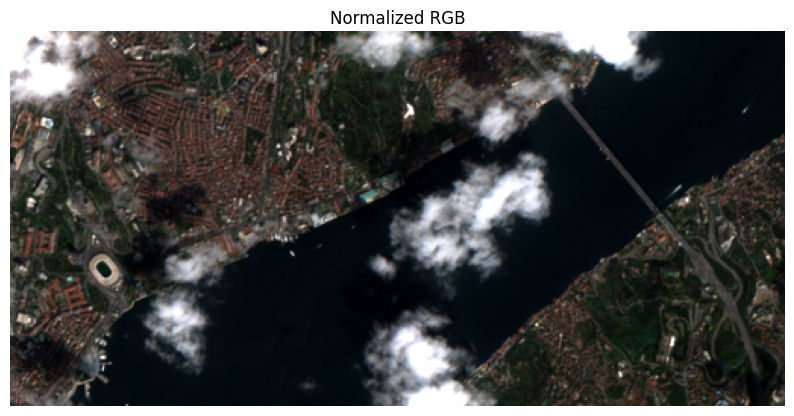

In [12]:
time_to_visualize = '2024-04-06'
bands = ["red", "green", "blue"]

da_time = stac.sel(time=time_to_visualize)
da_rgb = da_time.sel(band=bands)
rgb_image = da_rgb.values.transpose(1, 2, 0)

# Remove normalization for composites other than RGB
p2 = np.percentile(rgb_image, 2)
p98 = np.percentile(rgb_image, 98)
rgb_clipped = np.clip(rgb_image, p2, p98)
rgb_normalized = (rgb_clipped - p2) / (p98 - p2)

# Plot the image
plt.figure(figsize=(10, 5))
plt.imshow(rgb_normalized)
plt.title("Normalized RGB")
plt.axis("off")
plt.show()

**5.2 NDVI Visualization**

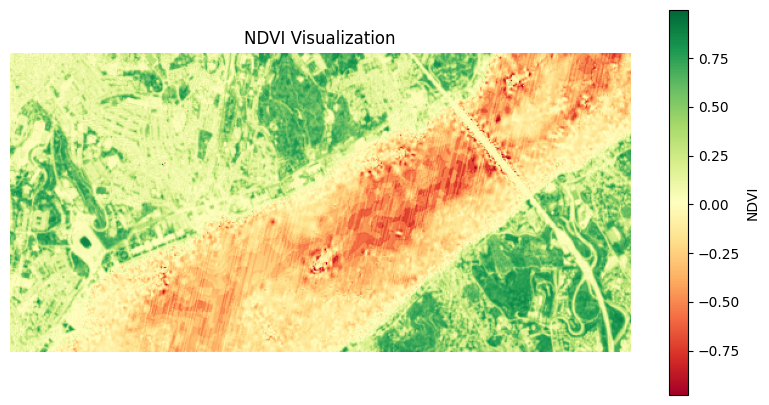

In [26]:
time_to_visualize = '2024-04-06'
ndvi_band = "ndvi"

da_time = stac.sel(time=time_to_visualize)
da_ndvi = da_time.sel(band=ndvi_band)
ndvi_data = da_ndvi.values

plt.figure(figsize=(10, 5))
plt.imshow(ndvi_data, cmap="RdYlGn")
plt.colorbar(label="NDVI")
plt.title("NDVI Visualization")
plt.axis("off")
plt.show()

**5.3 Other Examples**

**False Coloring**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0001..1.5384].


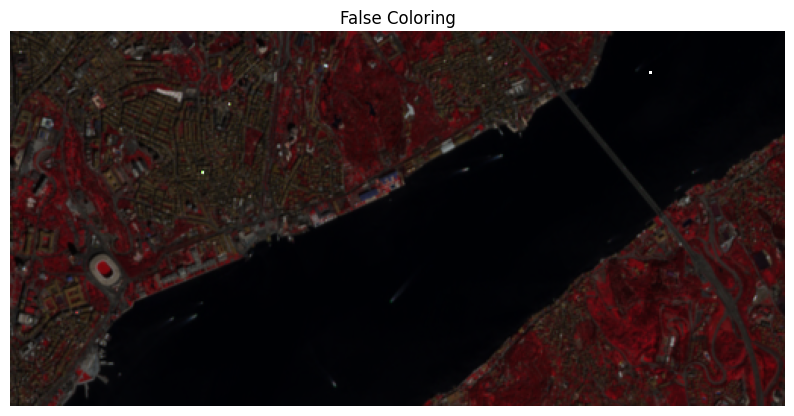

In [31]:
time_to_visualize = '2024-04-06'
bands = ["nir", "red", "green"]

da_time = stac.sel(time=time_to_visualize)
da_composite = da_time.sel(band=bands)
da_composite = da_composite.values.transpose(1, 2, 0)

# Plot the image
plt.figure(figsize=(10, 5))
plt.imshow(da_composite)
plt.title("False Coloring")
plt.axis("off")
plt.show()

**NDWI**

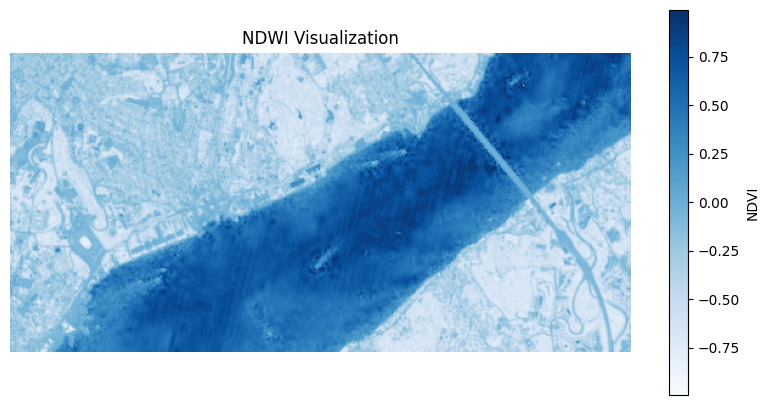

In [32]:
time_to_visualize = '2024-04-06'
ndwi_band = "ndwi"

da_time = stac.sel(time=time_to_visualize)
da_ndwi = da_time.sel(band=ndwi_band)
ndwi_data = da_ndwi.values

plt.figure(figsize=(10, 5))
plt.imshow(ndwi_data, cmap="Blues")
plt.colorbar(label="NDVI")
plt.title("NDWI Visualization")
plt.axis("off")
plt.show()

## 6. Graphs and Animation

**6.1 Graphs**

**6.1.1 Time Series Graph**

> **Note:**
> Following mean calculation over x and y coordinates requires **computation**. Therefore, if stac is lazy array, then it will take time. For faster experience, export with SLURM, then read NETCDF file and get Spectral Temporal Stack.

In [23]:
ds = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/orog_1_noclip.nc")
da = ds.Spectral_Temporal_Stack

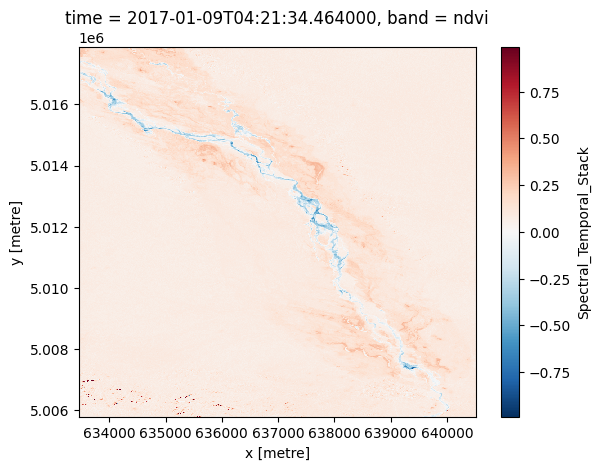

In [15]:
da[0][4].plot()

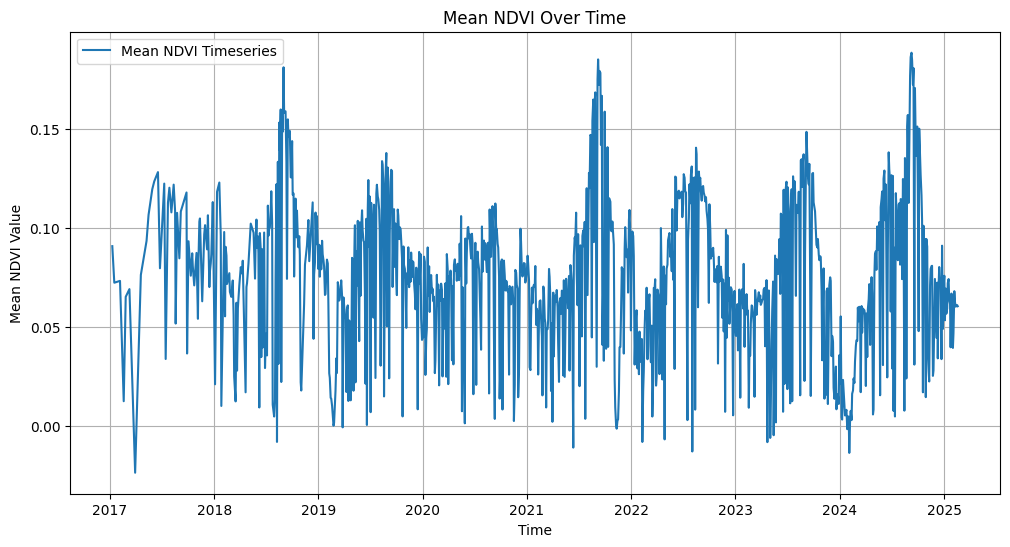

In [4]:
band = "ndvi"

da_sel = da.sel(band=band)
da_sel = da_sel.mean(dim=["x", "y"])

# Plot the values over time
plt.figure(figsize=(12, 6))
plt.plot(da_sel["time"], da_sel, label="Mean NDVI Timeseries")
plt.xlabel("Time")
plt.ylabel("Mean NDVI Value")
plt.title("Mean NDVI Over Time")
plt.legend()
plt.grid()
plt.show()

**Smoothed series**

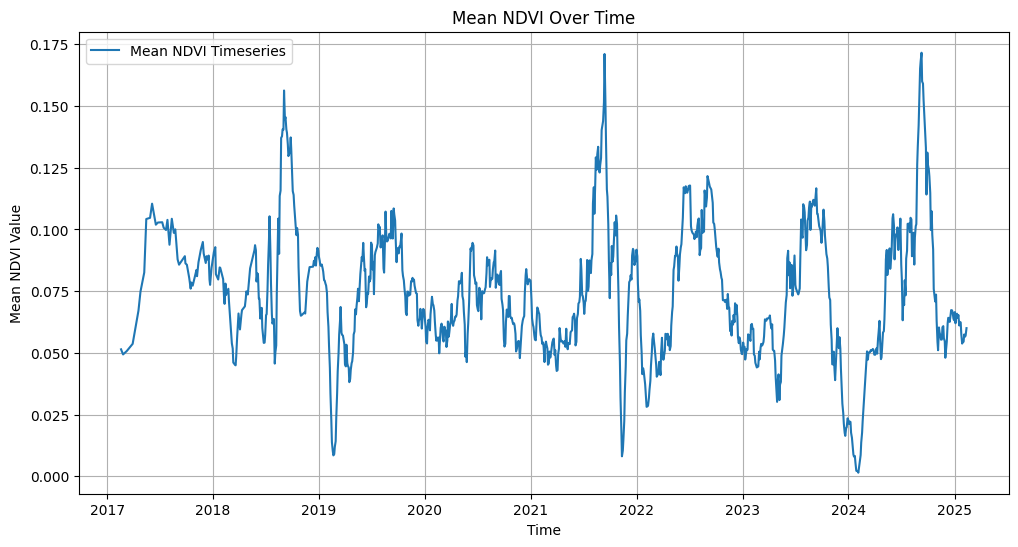

In [5]:
smoothed_da = da_sel.rolling(time=7, center=True).mean()
plt.figure(figsize=(12, 6))
plt.plot(smoothed_da["time"], smoothed_da, label="Mean NDVI Timeseries")
plt.xlabel("Time")
plt.ylabel("Mean NDVI Value")
plt.title("Mean NDVI Over Time")
plt.legend()
plt.grid()
plt.show()

**6.1.2 Box Plots**

**6.2 Animation**

> **Note:**
> Animation can be activated with **get_stac_layers** but not recommended.

> **Note 2:**
> Graphs used for the animation can be found under figures folder

> **Note 3:**
> Do not forget to clear figure folder each time an animation is requested otherwise everything will be part of animation

In [10]:
from stac2ardcube import generate_animation

MovieWriter imagemagick unavailable; using Pillow instead.


Number of images: 59


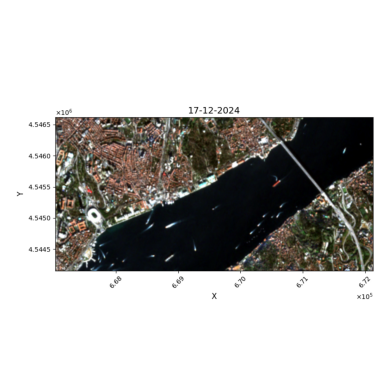

In [11]:
daterange = ["2024-01-01", "2025-01-01"]
output_folder = "./animations/"
animation = "rgb" # Animation could be one of the following: "rgb", "ndvi" "ndwi"

stac_animation = stac.sel(time=slice(*daterange))
generate_animation(stac_animation, output_folder, animation)